In [21]:
# Чтение и запись данных

import pandas as pd

df = pd.read_csv("reviews_with_aspects.csv")

df.to_csv("test.csv")

In [22]:
# Основные действия с данными

df.info()

print(df.describe().transpose())

cleared_df = df.drop(["review"], axis=1)
print(cleared_df.head())
print(cleared_df.tail())

sorted_df = cleared_df.sort_values(by="predicted_sentiment")
print(sorted_df.head())
print(sorted_df.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5037 entries, 0 to 5036
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   review               5037 non-null   object
 1   clean_review         5037 non-null   object
 2   sentiment_raw        5037 non-null   object
 3   predicted_sentiment  5037 non-null   object
 4   clinic               5037 non-null   int64 
 5   doctor               5037 non-null   int64 
 6   service              5037 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 275.6+ KB
          count      mean       std  min  25%  50%  75%  max
clinic   5037.0  0.479055  0.499611  0.0  0.0  0.0  1.0  1.0
doctor   5037.0  0.690093  0.462501  0.0  0.0  1.0  1.0  1.0
service  5037.0  0.311296  0.463070  0.0  0.0  0.0  1.0  1.0
                                        clean_review  \
0  обратиться поликлиника   специалист сергей вик...   
1  обратиться клиника приятно удивлённый каче

In [23]:
# вывод отельных строки и столбцов из таблицы

print(df["review"])

print(df.loc[100])

print(df.loc[100, "sentiment_raw"])

print(df.loc[100:200, ["predicted_sentiment", "clinic", "doctor", "service"]])

print(df[0:3])

print(df.iloc[0])

print(df.iloc[3:5, 0:2])

print(df.iloc[[3, 4], [0, 1]])

0       Обратились в поликлинику, специалист Сергей Ви...
1       Обратился в эту клинику и был приятно удивлен ...
2       Прийти на прием к проктологу - это ведь не к т...
3       От всей души благодарю весь коллектив "Уро-Про...
4       Хочу выразить благодарность доктору Можаевой Е...
                              ...                        
5032    Очень вежливый персонал. Приходила с грудным р...
5033    Отличный доктор, были у детского невролога. Вс...
5034    Чисто. Бахилы есть как для взрослых, так и для...
5035    Очень достойная клиника, грамотные врачи. Вним...
5036    Посещаю "Преамбулу" с детьми. Прием всегда во ...
Name: review, Length: 5037, dtype: object
review                 Обратилась в клинику "УРО-ПРО" с проблемой три...
clean_review           обратиться клиника   уро   проблема тридцатиле...
sentiment_raw          {'label': 'POSITIVE', 'score': 0.9813514351844...
predicted_sentiment                                             POSITIVE
clinic                      

In [24]:
# группировка и агрегация данных в таблице

s_values = df["predicted_sentiment"].unique()
print(s_values)

s_total = 0
for s_value in s_values:
    count = df[df["predicted_sentiment"] == s_value].shape[0]
    s_total += count
    print(s_value, "count =", count)
print("Total count = ", s_total)

print(df.groupby(["predicted_sentiment", "clinic"]).size().reset_index(name="Count")) # type: ignore

['POSITIVE' 'NEGATIVE' 'NEUTRAL']
POSITIVE count = 4137
NEGATIVE count = 728
NEUTRAL count = 172
Total count =  5037
  predicted_sentiment  clinic  Count
0            NEGATIVE       0    518
1            NEGATIVE       1    210
2             NEUTRAL       0    111
3             NEUTRAL       1     61
4            POSITIVE       0   1995
5            POSITIVE       1   2142


In [25]:
# визуализация

data = df[["predicted_sentiment", "clinic", "doctor", "service"]].copy()
print(data)

     predicted_sentiment  clinic  doctor  service
0               POSITIVE       1       0        0
1               POSITIVE       1       1        1
2               POSITIVE       0       1        0
3               POSITIVE       0       1        0
4               POSITIVE       0       1        0
...                  ...     ...     ...      ...
5032            POSITIVE       0       0        1
5033            POSITIVE       0       1        0
5034            POSITIVE       0       1        0
5035            POSITIVE       1       1        0
5036            POSITIVE       0       1        0

[5037 rows x 4 columns]


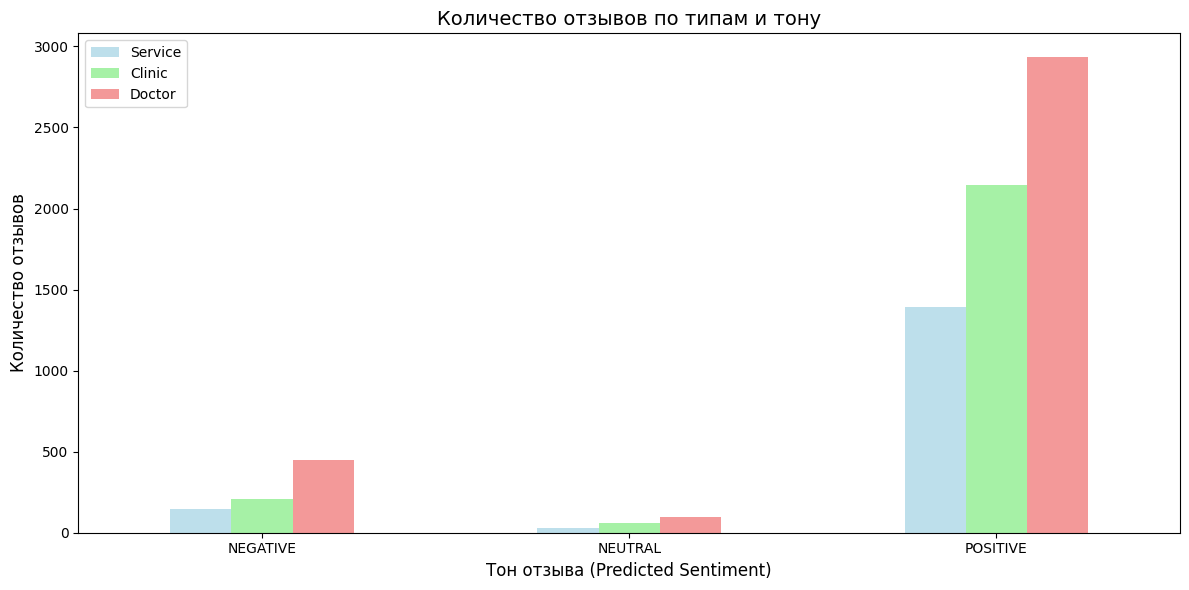

In [27]:
import matplotlib.pyplot as plt

grouped_counts = df.groupby("predicted_sentiment")[["service", "clinic", "doctor"]].sum()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["lightblue", "lightgreen", "lightcoral"]

grouped_counts.plot(kind="bar", ax=ax, color=colors, alpha=0.8)

ax.set_title("Количество отзывов по типам и тону", fontsize=14)
ax.set_xlabel("Тон отзыва (Predicted Sentiment)", fontsize=12)
ax.set_ylabel("Количество отзывов", fontsize=12)
ax.legend(["Service", "Clinic", "Doctor"], fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()
